Search on March 20, 2026

Limited to **diabetes or diabetes foot ulcer**: Pubmed keywords : (("diabetic foot ulcer"[Title/Abstract] OR diabetes[Title/Abstract]) AND ("machine learning"[Title/Abstract] OR "artificial intelligence"[Title/Abstract])) AND ("health equity"[Title] OR equality[Title] OR equity[Title] OR diversity[Title]) -> **14 results**

If **not limited to diabetes or diabetes foot ulcer**: Pubmed keywords:(("machine learning"[Title/Abstract] OR "artificial intelligence"[Title/Abstract])) AND ("health equity"[Title] OR equality[Title] OR equity[Title] OR diversity[Title]) NOT ((("diabetic foot ulcer"[Title/Abstract] OR diabetes[Title/Abstract]) AND ("machine learning"[Title/Abstract] OR "artificial intelligence"[Title/Abstract])) AND ("health equity"[Title] OR equality[Title] OR equity[Title] OR diversity[Title])) ->**655 results**


In [ ]:
# !pip install -q contractions nltk gensim
# Import key packages for data processing and NLP
import pandas as pd  # Library for handling structured data (e.g., DataFrames) efficiently

# Import the necessary libraries for text preprocessing
import contractions  # Allows us to handle text contractions (e.g., "can't" -> "cannot")
import re  # Used for finding and replacing text patterns (e.g., removing special characters)
from datetime import datetime  # Provides functions for handling date and time operations

# Import NLTK (Natural Language Toolkit) for text tokenization
import nltk
from nltk.tokenize import word_tokenize  # Tokenizes text into individual words
nltk.download('punkt')  # Downloads the tokenizer model which we'll be using
nltk.download('punkt_tab')

# Import the 'stopwords' corpus from NLTK (Natural Language Toolkit)
from nltk.corpus import stopwords
nltk.download('stopwords')  # Downloads the predefined list of common stopwords from NLTK.

# WordCloud for visualizing the frequency of words in text data
from wordcloud import WordCloud
import matplotlib.pyplot as plt  # Library for plotting and visualization

# Libraries for lemmatization (reducing words to their base form)
from nltk.stem import WordNetLemmatizer  # Performs lemmatization
from nltk.corpus import wordnet  # Provides a lexical database for lemmatization
nltk.download('averaged_perceptron_tagger')  # Downloads the model for part-of-speech tagging
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')  # Downloads the WordNet lexical database

# Libraries for word embeddings (vector representations of words)
import gensim.downloader as api  # Getting our pre-trained word embedding models
import numpy as np  # Numerical computing library for handling arrays and matrices

# package to handle warnings
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))
print(f"Reading: {filename}")

df = pd.read_csv(io.BytesIO(uploaded[filename]))

df.head()

Saving NLP_Phase3_final20+Papers_Discussion.csv to NLP_Phase3_final20+Papers_Discussion.csv
Reading: NLP_Phase3_final20+Papers_Discussion.csv


,PMID,Title,Abstract,Discussion
0,41314754,"Future horizons: Innovation, aging, and equity.",Precision medicine is on the verge of transfor...,The future of precision medicine for neurodege...
1,41282840,"Nonfasting, Telehealth-Ready LDL-C Testing Wit...",Current LDL-C testing requires 9-12 hour fasti...,Our findings demonstrate that ML can eliminate...
2,40664423,Integrating artificial intelligence in communi...,Marginalised populations-such as racialised gr...,"This realist review protocol examines how, why..."
3,40648554,Precision Medicine: Personalizing Healthcare b...,Precision medicine transforms healthcare by ta...,Precision medicine can only succeed if it incl...
4,39959516,Autonomous Artificial Intelligence for Diabeti...,This article discusses the implementation and ...,The FDA first cleared an autonomous AI system ...


**Text Processing**

In [ ]:
# Combine title, abstract and discussion
df['text'] = df['Title'].fillna('') + ' ' + df['Abstract'].fillna('') + ' ' + df['Discussion'].fillna('')

# Removing special characters
def remove_special_characters(text):
    return re.sub(r'[^A-Za-z\s]', '', text)

# Lower case and remove special characters
df['cleaned_text'] = df['text'].str.lower()
df['cleaned_text'] = df['cleaned_text'].apply(remove_special_characters)

# Tokenization
def tokenize_text(text):
   return word_tokenize(text)

df['tokens'] = df['cleaned_text'].apply(tokenize_text)

# Remove stop words
stop_words_set = set(stopwords.words('english'))
# Define additional context-sensitive stop words
context_sensitive_stop_words = set([
    'study', 'studies', 'research', 'model', 'models', 'data', 'algorithm',
    'learning', 'machine', 'health', 'patient', 'patients', 'use', 'used',
    'paper', 'result', 'results', 'method', 'methods', 'analysis', 'based', 'also',
    'may', 'could', 'would', 'might', 'across', 'among', 'within', 'using',
    'often', 'well', 'however', 'although', 'thus', 'therefore', 'e', 'g', 'e.g',
    'approach', 'approaches', 'system', 'systems', 'including', 'included',
    'different', 'multiple', 'multi', 'single', 'one', 'two', 'time', 'work',
    'findings', 'found', 'showed', 'shown', 'suggest', 'suggests', 'likely',
    'support', 'supported', 'associated', 'associated', 'compared', 'compare',
    'clinical', 'healthcare', 'care', 'disease', 'outcomes', 'performance',
    'accuracy',  'technology', 'tools', 'management', 'impact',
    'potential', 'future', 'review'
])
all_stop_words = stop_words_set | context_sensitive_stop_words

def remove_context_sensitive_stop_words(tokens):
    return [token for token in tokens if token.lower() not in all_stop_words and len(token) > 1]

df['tokens_no_stop_context'] = df['tokens'].apply(remove_context_sensitive_stop_words)

# Lemmatization
def get_wordnet_pos(word, pos_tag):
    if pos_tag.startswith('J'):
        return wordnet.ADJ
    elif pos_tag.startswith('V'):
        return wordnet.VERB
    elif pos_tag.startswith('N'):
        return wordnet.NOUN
    elif pos_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens_with_pos(tokens):
    tagged_tokens = nltk.pos_tag(tokens)
    return [lemmatizer.lemmatize(word, get_wordnet_pos(word, tag)) for word, tag in tagged_tokens]

df['lemmatized'] = df['tokens_no_stop_context'].apply(lemmatize_tokens_with_pos)

df['lemmatized_str'] = df['lemmatized'].apply(lambda x: ' '.join(x))
df[['PMID', 'Title', 'lemmatized_str']].to_csv('preprocessed_papers_cleaned.csv', index=False)

**Word Cloud**

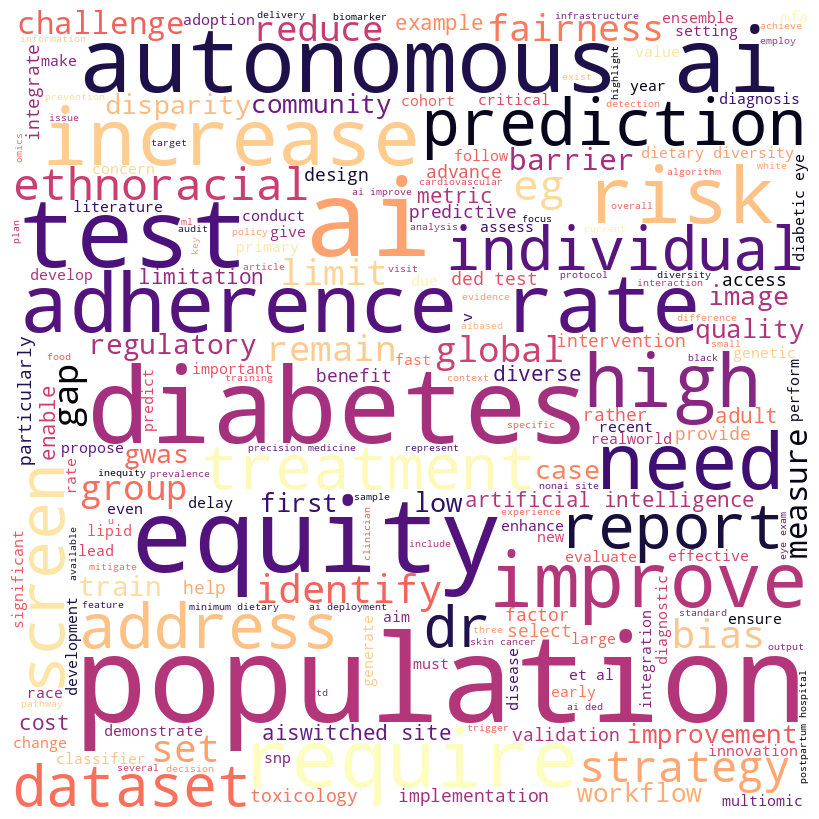

In [ ]:
all_tokens = sum(df['lemmatized'].tolist(), [])
text_for_wc = ' '.join(all_tokens)

wordcloud = WordCloud(width = 800, height = 800,
                      background_color ='white',
                      colormap='magma',
                      min_font_size = 10).generate(text_for_wc)
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()